# Feature Engineering - Khoa

Phần nhiệm vụ chính theo paper: 
- Train 4 model cây tren `X_train_*_smote`
- Tính average importance của `DT`, `RF`, `ET`, `XGB`
- Chon feature theo cumulative threshold
- Mapping `X_train` va `X_test`
- Xuat 3 file output chinh:
  - `X_train_selected.csv`
  - `X_test_selected.csv`
  - `selected_features_list.txt`

Phần phụ
- `Gain Ratio`
- `CFS`
- `feature_importance.csv`


In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import pearsonr
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

print('xgboost version:', xgb.__version__)

CAN_FEATURE_NAMES = [
    'Timestamp', 'CAN_ID', 'DLC',
    'Byte1', 'Byte2', 'Byte3', 'Byte4', 'Byte5', 'Byte6', 'Byte7', 'Byte8'
]


@dataclass
class DatasetBundle:
    name: str
    x_train: pd.DataFrame
    y_train: pd.Series
    x_test: pd.DataFrame
    y_test: pd.Series


def read_x_csv(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [str(c) for c in df.columns]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')
    return df.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def read_y_csv(path: str | Path) -> pd.Series:
    y = pd.read_csv(path, header=None).squeeze('columns')
    return pd.to_numeric(y, errors='coerce').fillna(0).astype(int)


def align_xy(x: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
    size = min(len(x), len(y))
    return x.iloc[:size].copy(), y.iloc[:size].copy()


def rename_can_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if len(out.columns) == len(CAN_FEATURE_NAMES):
        out.columns = CAN_FEATURE_NAMES
    return out


def add_time_delta(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'Time_Delta' in out.columns:
        return out
    if 'Timestamp' not in out.columns or 'CAN_ID' not in out.columns:
        return out
    out['Timestamp'] = pd.to_numeric(out['Timestamp'], errors='coerce').fillna(0.0)
    out['CAN_ID'] = pd.to_numeric(out['CAN_ID'], errors='coerce').fillna(0.0)
    out = out.sort_values(['CAN_ID', 'Timestamp']).copy()
    out['Time_Delta'] = out.groupby('CAN_ID')['Timestamp'].diff().fillna(0.0)
    return out.reset_index(drop=True)


def load_dataset(name: str, x_train_path: str, y_train_path: str, x_test_path: str, y_test_path: str) -> DatasetBundle:
    x_train = read_x_csv(x_train_path)
    y_train = read_y_csv(y_train_path)
    x_test = read_x_csv(x_test_path)
    y_test = read_y_csv(y_test_path)
    x_train, y_train = align_xy(x_train, y_train)
    x_test, y_test = align_xy(x_test, y_test)
    if name.upper() == 'CAN':
        x_train = rename_can_columns(x_train)
        x_test = rename_can_columns(x_test)
        x_train = add_time_delta(x_train)
        x_test = add_time_delta(x_test)
    return DatasetBundle(name=name, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)


def describe_bundle(bundle: DatasetBundle) -> pd.DataFrame:
    summary = [
        ('dataset', bundle.name),
        ('x_train_shape', str(bundle.x_train.shape)),
        ('y_train_shape', str(bundle.y_train.shape)),
        ('x_test_shape', str(bundle.x_test.shape)),
        ('y_test_shape', str(bundle.y_test.shape)),
        ('same_columns', list(bundle.x_train.columns) == list(bundle.x_test.columns)),
        ('num_features', bundle.x_train.shape[1]),
        ('num_classes', int(bundle.y_train.nunique())),
    ]
    return pd.DataFrame(summary, columns=['item', 'value'])


def train_tree_models(x_train: pd.DataFrame, y_train: pd.Series, random_state: int = 42) -> Dict[str, object]:
    num_classes = int(pd.Series(y_train).nunique())
    xgb_params = {
        'n_estimators': 200,
        'max_depth': 8,
        'random_state': random_state,
        'n_jobs': -1,
        'tree_method': 'hist',
    }
    if num_classes > 2:
        xgb_params.update({'objective': 'multi:softprob', 'num_class': num_classes, 'eval_metric': 'mlogloss'})
    else:
        xgb_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss'})

    models = {
        'DT': DecisionTreeClassifier(criterion='gini', max_depth=8, min_samples_split=8, min_samples_leaf=3, random_state=random_state),
        'RF': RandomForestClassifier(n_estimators=200, criterion='gini', max_depth=8, min_samples_split=8, min_samples_leaf=3, random_state=random_state, n_jobs=-1),
        'ET': ExtraTreesClassifier(n_estimators=200, criterion='gini', max_depth=8, min_samples_split=8, min_samples_leaf=3, random_state=random_state, n_jobs=-1),
        'XGB': xgb.XGBClassifier(**xgb_params),
    }
    trained = {}
    for name, model in models.items():
        print(f'Training {name} ...')
        model.fit(x_train, y_train)
        trained[name] = model
    return trained


def compute_average_importance(models: Dict[str, object], feature_names: Sequence[str]) -> pd.DataFrame:
    importance_df = pd.DataFrame(index=list(feature_names))
    for name, model in models.items():
        importance_df[name] = model.feature_importances_
    for col in importance_df.columns:
        total = float(importance_df[col].sum())
        if total > 0:
            importance_df[col] = importance_df[col] / total
    importance_df['avg_importance'] = importance_df.mean(axis=1)
    importance_df = importance_df.sort_values('avg_importance', ascending=False)
    importance_df['cumulative'] = importance_df['avg_importance'].cumsum()
    return importance_df


def select_features_by_threshold(importance_df: pd.DataFrame, threshold: float = 0.9) -> List[str]:
    selected = importance_df[importance_df['cumulative'] <= threshold].index.tolist()
    if not selected and len(importance_df) > 0:
        selected = [importance_df.index[0]]
    elif len(selected) < len(importance_df):
        selected.append(importance_df.index[len(selected)])
    return [str(c) for c in selected]


def map_selected_features(x_train: pd.DataFrame, x_test: pd.DataFrame, selected_features: Sequence[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    return x_train[list(selected_features)].copy(), x_test[list(selected_features)].copy()


def save_selection_outputs(out_dir: str | Path, x_train_selected: pd.DataFrame, x_test_selected: pd.DataFrame, selected_features: Sequence[str]) -> None:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    x_train_selected.to_csv(out_dir / 'X_train_selected.csv', index=False)
    x_test_selected.to_csv(out_dir / 'X_test_selected.csv', index=False)
    with open(out_dir / 'selected_features_list.txt', 'w', encoding='utf-8') as f:
        for feat in selected_features:
            f.write(f'{feat}\n')


def plot_average_importance(importance_df: pd.DataFrame, title: str, top_n: int = 20):
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = importance_df.head(top_n).sort_values('avg_importance', ascending=True)
    ax.barh(plot_df.index.astype(str), plot_df['avg_importance'], color='#4472C4')
    ax.set_title(title)
    ax.set_xlabel('Average Importance')
    ax.set_ylabel('Feature')
    fig.tight_layout()
    return fig


def entropy_from_counts(counts: np.ndarray) -> float:
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def gain_ratio_for_feature(x: pd.Series, y: pd.Series, n_bins: int = 10) -> float:
    x = pd.Series(x).fillna(0)
    y = pd.Series(y).astype(int)
    if x.nunique(dropna=False) > n_bins:
        discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        x_disc = discretizer.fit_transform(x.to_numpy().reshape(-1, 1)).astype(int).ravel()
    else:
        x_disc = x.astype('category').cat.codes.to_numpy()
    hy = entropy_from_counts(np.bincount(y))
    conditional_entropy = 0.0
    split_info = 0.0
    n = len(x_disc)
    for value in np.unique(x_disc):
        mask = x_disc == value
        subset_y = y[mask]
        weight = len(subset_y) / n
        conditional_entropy += weight * entropy_from_counts(np.bincount(subset_y))
        if weight > 0:
            split_info -= weight * math.log2(weight)
    info_gain = hy - conditional_entropy
    if split_info == 0:
        return 0.0
    return float(info_gain / split_info)


def compute_gain_ratio_all_features(x_train: pd.DataFrame, y_train: pd.Series, n_bins: int = 10) -> pd.DataFrame:
    scores = {col: gain_ratio_for_feature(x_train[col], y_train, n_bins=n_bins) for col in x_train.columns}
    return pd.DataFrame.from_dict(scores, orient='index', columns=['gain_ratio']).sort_values('gain_ratio', ascending=False)


def safe_abs_pearson(x: Iterable[float], y: Iterable[float]) -> float:
    x = pd.Series(x)
    y = pd.Series(y)
    if x.nunique() <= 1 or y.nunique() <= 1:
        return 0.0
    try:
        corr = pearsonr(x, y)[0]
    except Exception:
        return 0.0
    if pd.isna(corr):
        return 0.0
    return float(abs(corr))


def cfs_merit(x_train: pd.DataFrame, y_train: pd.Series, features: Sequence[str]) -> float:
    if len(features) == 0:
        return 0.0
    x_sub = x_train[list(features)]
    k = len(features)
    r_cf = float(np.mean([safe_abs_pearson(x_sub[col], y_train) for col in features]))
    if k == 1:
        r_ff = 0.0
    else:
        corr_vals = []
        cols = list(features)
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                corr_vals.append(safe_abs_pearson(x_sub[cols[i]], x_sub[cols[j]]))
        r_ff = float(np.mean(corr_vals)) if corr_vals else 0.0
    return float((k * r_cf) / math.sqrt(k + k * (k - 1) * r_ff + 1e-12))


def cfs_forward_selection(x_train: pd.DataFrame, y_train: pd.Series, max_features: int = 20) -> Tuple[List[str], float]:
    remaining = list(x_train.columns)
    selected: List[str] = []
    best_merit = -1.0
    while remaining and len(selected) < max_features:
        scored = []
        for feat in remaining:
            merit = cfs_merit(x_train, y_train, selected + [feat])
            scored.append((feat, merit))
        scored.sort(key=lambda item: item[1], reverse=True)
        best_feat, merit = scored[0]
        if merit > best_merit:
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_merit = merit
        else:
            break
    return selected, best_merit


xgboost version: 3.1.2


In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'feature_engineering_output'
OUTPUT_DIR.mkdir(exist_ok=True)

can_bundle = load_dataset(
    name='CAN',
    x_train_path='X_train_CAN_smote.csv',
    y_train_path='Y_train_CAN.csv',
    x_test_path='X_test_CAN.csv',
    y_test_path='Y_test_CAN.csv',
)

cicids_bundle = load_dataset(
    name='CICIDS',
    x_train_path='X_train_CICIDS_smote-002.csv',
    y_train_path='Y_train_CICIDS.csv',
    x_test_path='X_test_CICIDS.csv',
    y_test_path='Y_test_CICIDS.csv',
)


In [3]:
display(describe_bundle(can_bundle))
display(describe_bundle(cicids_bundle))
print('CAN columns:', list(can_bundle.x_train.columns))
print('Time_Delta in CAN:', 'Time_Delta' in can_bundle.x_train.columns)


,item,value
0,dataset,CAN
1,x_train_shape,"(13255580, 12)"
2,y_train_shape,"(13255580,)"
3,x_test_shape,"(3313895, 12)"
4,y_test_shape,"(3313895,)"
5,same_columns,True
6,num_features,12
7,num_classes,5


,item,value
0,dataset,CICIDS
1,x_train_shape,"(2265785, 78)"
2,y_train_shape,"(2265785,)"
3,x_test_shape,"(566149, 78)"
4,y_test_shape,"(566149,)"
5,same_columns,True
6,num_features,78
7,num_classes,15


CAN columns: ['Timestamp', 'CAN_ID', 'DLC', 'Byte1', 'Byte2', 'Byte3', 'Byte4', 'Byte5', 'Byte6', 'Byte7', 'Byte8', 'Time_Delta']
Time_Delta in CAN: True


## CAN - Part 1: Train 4 models


In [4]:
models_can = train_tree_models(can_bundle.x_train, can_bundle.y_train)


Training DT ...
Training RF ...
Training ET ...
Training XGB ...


## CAN - Part 2: Average importance + selection + save main outputs


In [5]:
importance_can = compute_average_importance(models_can, can_bundle.x_train.columns)
selected_features_can = select_features_by_threshold(importance_can, threshold=0.9)

X_train_CAN_selected, X_test_CAN_selected = map_selected_features(
    can_bundle.x_train,
    can_bundle.x_test,
    selected_features_can,
)

save_selection_outputs(
    out_dir=OUTPUT_DIR / 'CAN',
    x_train_selected=X_train_CAN_selected,
    x_test_selected=X_test_CAN_selected,
    selected_features=selected_features_can,
)

importance_can.to_csv(OUTPUT_DIR / 'CAN' / 'feature_importance.csv')

print('Selected CAN features:', selected_features_can)
display(importance_can.head(20))


Selected CAN features: ['Timestamp', 'Byte5', 'Time_Delta', 'Byte8', 'Byte3', 'Byte7', 'CAN_ID', 'Byte1', 'Byte6', 'Byte4']


,DT,RF,ET,XGB,avg_importance,cumulative
Timestamp,0.220531,0.195967,0.097728,0.079906,0.148533,0.148533
Byte5,0.173263,0.080700,0.092425,0.091729,0.109529,0.258062
Time_Delta,0.154770,0.114005,0.082434,0.073414,0.106156,0.364218
Byte8,0.076616,0.088147,0.097576,0.091100,0.088360,0.452578
Byte3,0.095349,0.068097,0.087089,0.085101,0.083909,0.536487
Byte7,0.084248,0.077387,0.087394,0.086259,0.083822,0.620308
CAN_ID,0.057968,0.092588,0.090307,0.085564,0.081607,0.701915
Byte1,0.051431,0.075772,0.093567,0.089702,0.077618,0.779533
Byte6,0.037594,0.073760,0.091115,0.088019,0.072622,0.852155
Byte4,0.032255,0.062620,0.082301,0.094784,0.067990,0.920145


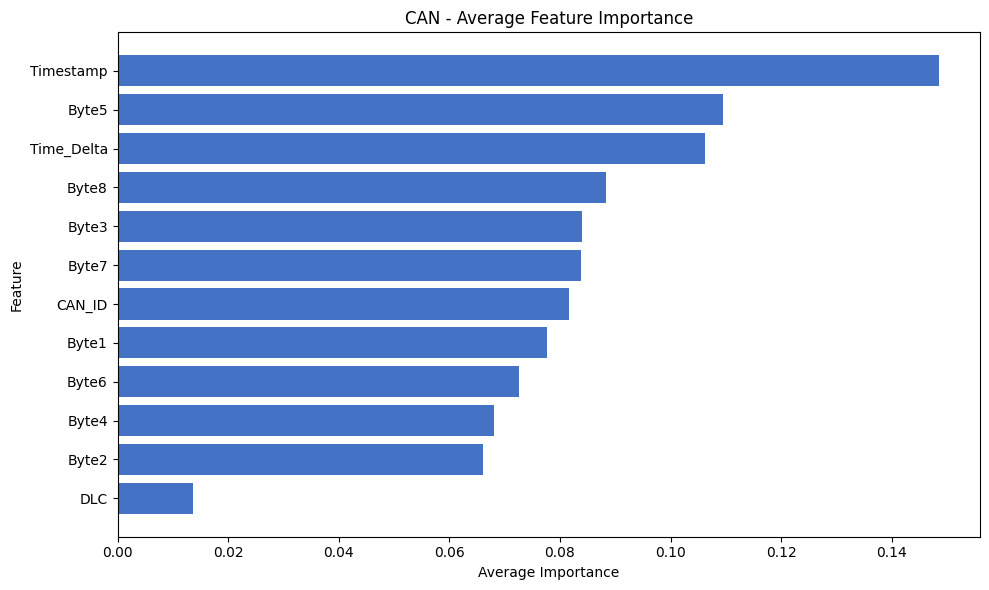

In [6]:
fig = plot_average_importance(importance_can, title='CAN - Average Feature Importance', top_n=20)
plt.show()


## CAN - Part 3: Gain Ratio


In [7]:
gain_ratio_can = compute_gain_ratio_all_features(can_bundle.x_train, can_bundle.y_train)
gain_ratio_can.to_csv(OUTPUT_DIR / 'CAN' / 'gain_ratio.csv')
display(gain_ratio_can.head(20))


c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretizat

,gain_ratio
DLC,3.453349e-06
Byte6,9.834221e-07
Timestamp,7.231536e-07
Byte1,7.037589e-07
Byte4,6.965041e-07
Time_Delta,6.692283e-07
Byte8,6.217072e-07
Byte5,6.023517e-07
Byte7,5.730397e-07
CAN_ID,5.141462e-07


## CAN - Part 4: CFS


In [8]:
cfs_features_can, cfs_score_can = cfs_forward_selection(
    can_bundle.x_train,
    can_bundle.y_train,
    max_features=min(20, can_bundle.x_train.shape[1]),
)

with open(OUTPUT_DIR / 'CAN' / 'cfs_features.txt', 'w', encoding='utf-8') as f:
    f.write(f'CFS merit: {cfs_score_can}\n')
    for feat in cfs_features_can:
        f.write(f'{feat}\n')

print('CFS CAN score:', cfs_score_can)
print('CFS CAN features:', cfs_features_can)


CFS CAN score: 0.0007896593168797403
CFS CAN features: ['Byte6', 'DLC', 'Byte4', 'Byte7']


## CICIDS - Part 1: Train 4 models


In [9]:
models_cicids = train_tree_models(cicids_bundle.x_train, cicids_bundle.y_train)


Training DT ...
Training RF ...
Training ET ...
Training XGB ...


## CICIDS - Part 2: Average importance + selection + save main outputs


In [10]:
importance_cicids = compute_average_importance(models_cicids, cicids_bundle.x_train.columns)
selected_features_cicids = select_features_by_threshold(importance_cicids, threshold=0.9)

X_train_CICIDS_selected, X_test_CICIDS_selected = map_selected_features(
    cicids_bundle.x_train,
    cicids_bundle.x_test,
    selected_features_cicids,
)

save_selection_outputs(
    out_dir=OUTPUT_DIR / 'CICIDS',
    x_train_selected=X_train_CICIDS_selected,
    x_test_selected=X_test_CICIDS_selected,
    selected_features=selected_features_cicids,
)

importance_cicids.to_csv(OUTPUT_DIR / 'CICIDS' / 'feature_importance.csv')

print('Selected CICIDS features:', selected_features_cicids)
display(importance_cicids.head(20))


Selected CICIDS features: ['13', '74', '52', '41', '46', '6', '12', '0', '68', '54', '37', '10', '42', '39', '40', '66', '16', '4', '77', '18', '47', '22', '23', '76', '63', '2', '11', '3', '53', '17', '67', '8']


,DT,RF,ET,XGB,avg_importance,cumulative
13,0.291582,0.049853,0.041100,0.119922,0.125614,0.125614
74,0.000000,0.015099,0.033510,0.326426,0.093759,0.219373
52,0.180850,0.042216,0.042055,0.056502,0.080406,0.299779
41,0.128708,0.063885,0.041097,0.019519,0.063302,0.363081
46,0.009756,0.016371,0.078858,0.091699,0.049171,0.412252
6,0.122564,0.031708,0.010954,0.018800,0.046006,0.458258
12,0.000001,0.040768,0.047555,0.083336,0.042915,0.501173
0,0.101529,0.033632,0.020673,0.005151,0.040246,0.541420
68,0.000007,0.018315,0.005078,0.093124,0.029131,0.570551
54,0.003229,0.052511,0.053950,0.000000,0.027423,0.597973


In [ ]:
fig = plot_average_importance(importance_cicids, title='CICIDS - Average Feature Importance', top_n=20)
plt.show()


## CICIDS - Part 3: Gain Ratio


In [11]:
gain_ratio_cicids = compute_gain_ratio_all_features(cicids_bundle.x_train, cicids_bundle.y_train)
gain_ratio_cicids.to_csv(OUTPUT_DIR / 'CICIDS' / 'gain_ratio.csv')
display(gain_ratio_cicids.head(20))


c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally 

,gain_ratio
13,0.290319
67,0.227302
43,0.220670
0,0.200103
54,0.173390
12,0.173333
10,0.170539
76,0.169321
74,0.167493
77,0.163828


## CICIDS - Part 4: CFS


In [12]:
cfs_features_cicids, cfs_score_cicids = cfs_forward_selection(
    cicids_bundle.x_train,
    cicids_bundle.y_train,
    max_features=min(20, cicids_bundle.x_train.shape[1]),
)

with open(OUTPUT_DIR / 'CICIDS' / 'cfs_features.txt', 'w', encoding='utf-8') as f:
    f.write(f'CFS merit: {cfs_score_cicids}\n')
    for feat in cfs_features_cicids:
        f.write(f'{feat}\n')

print('CFS CICIDS score:', cfs_score_cicids)
print('CFS CICIDS features:', cfs_features_cicids)


CFS CICIDS score: 0.36805329641057016
CFS CICIDS features: ['46', '22', '38', '37']


## Output Files

Moi dataset se co 3 file output chinh:
- `X_train_selected.csv`
- `X_test_selected.csv`
- `selected_features_list.txt`

Va 3 file phu:
- `feature_importance.csv`
- `gain_ratio.csv`
- `cfs_features.txt`
